In [1]:
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.metrics import (
    silhouette_score, 
    r2_score,
)

import xgboost as xgb
from umap import UMAP
import shap

# =========================
# Custom utilities
# =========================
import utils.cross_validation as cval
import utils.umap_utils as uutil
import utils.exp_utils as exp

# =========================
# Optional helpers (math functions already included above)
# =========================
from math import radians, sin, cos, sqrt, asin
import math


def select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=None):
    """
    Select exactly ONE point and remove ALL other points within buffer_km.
    
    Parameters:
    - df: DataFrame with coordinates
    - buffer_km: radius in km to remove points (default: 50)
    - lat_col: latitude column name
    - lon_col: longitude column name
    - random_seed: random seed for reproducibility
    - method: 'random' or 'first' or index
    
    Returns:
    - selected_df: DataFrame with 1 selected point
    - remaining_df: DataFrame with points > buffer_km away (kept)
    - removed_df: DataFrame with points <= buffer_km away (removed)
    """
    
    if random_seed is not None:
        np.random.seed(random_seed)
    

    selected_idx = np.random.choice(df.index, 1, replace=False)[0]
 
    # Get selected point coordinates
    selected_point = df.loc[selected_idx]
    lat_sel = selected_point[lat_col]
    lon_sel = selected_point[lon_col]
    
    # Classify all points
    selected_points = [selected_idx]
    removed_points = []
    remaining_points = []
    
    for idx in df.index:
        if idx == selected_idx:
            continue
        
        # Calculate distance to selected point
        dist = haversine(lat_sel, lon_sel, 
                        df.loc[idx, lat_col], 
                        df.loc[idx, lon_col])
        
        if dist <= buffer_km:
            removed_points.append(idx)  # Too close → remove
        else:
            remaining_points.append(idx)  # Far enough → keep
    
    # Create DataFrames
    selected_df = df.loc[selected_points].copy()
    removed_df = df.loc[removed_points].copy()
    remaining_df = df.loc[remaining_points].copy()
    
    print(f"✓ Removed {len(removed_df)} points within {buffer_km}km")
    
    return selected_df, remaining_df, removed_df


def train_test_split_v3(df, random_key, n_points_to_select=2, buffer_km=100):

    # selected, remaining, removed = select_points_stratified(sub_df, 
    #     n_per_biome=n_points_to_select,
    #     buffer_km=buffer_km,
    #     lat_col='lat',
    #     lon_col='lon',
    #     random_seed=random_key
    # )
    selected, remaining, removed = select_one_point_remove_buffer(df, 
                                   buffer_km=50, 
                                   lat_col='lat', lon_col='lon', 
                                   random_seed=random_key)
    

    test = selected.drop(columns=['lat', 'lon', 'biome'])
    test_biomes=selected[['biome']]
    train= remaining.drop(columns=['lat', 'lon', 'biome'])

    y=['transformed npp'] 
    X_train=train.drop(columns=y+['PID'])

    y_train = train['transformed npp'].values

    X_test= test.drop(columns=y+['PID' ])
    y_test = test['transformed npp'].values
    
    scaler= StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

    return X_train, y_train, X_test, y_test, test_biomes, scaler


def haversine(lat1, lon1, lat2, lon2):
    """Calculate great-circle distance between two points in km"""
    R = 6371  # Earth's radius in km
    
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    return R * c


/home/qli/Projects/env1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Essential Params and Dicts

color_map = {
    'Species Richness': 'grey',
    'Shannon Diversity': "#8040a0",
    "Raos_Q": 'darkolivegreen',
    "Simpson's Index":  "#cca9dd",
    'Functional_Evenness': "#94BC92"
}
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

with open("config/ex_config.yaml", "r") as f:
    config = yaml.safe_load(f)

biome_mapping = config["biome_mapping"]
random_key=config["random_key"]

biome_list=["Temperate broadleaf forests", "Temperate conifer forests", "Temperate grasslands",
            "Xeric shrublands", "Boreal and Tundra forests", "Tropical",
            "Mediterranean woodlands"]

In [3]:
fd_df = pd.read_csv('data/final/final_dataset.csv')
PID_df= pd.read_csv('data/lookup/PID_location_all.csv')

fd_df=fd_df.merge(PID_df[['PID','lat','lon', 'biome']], on='PID', how='left')
fd_df.drop(columns=['Functional_Richness'], inplace=True)
fd_df.dropna(subset=['transformed npp', 'pet_std' , 'Raos_Q', 'Functional_Evenness', 'Soil Moisture',
                    'Species Richness', 'Shannon Diversity', "Simpson's Index"], inplace=True)
fd_df = fd_df[fd_df["treecover2000"] > 60]



fd_df.drop_duplicates(subset=['PID'], inplace=True)
npp_df=pd.read_csv('data/processed/PID_npp_volatility.csv')

npp_df=npp_df[['PID', 'mean']]

fd_df=fd_df.merge(npp_df, on='PID', how='left')

ecoregions=cval.process_ecoregion("data/Ecoregions/Ecoregions2017.shp")

ecoregions=ecoregions[['ECO_NAME', 'geometry']]
#Preprocessing the data for Random forest regression

fd_df['biome'] = fd_df['biome'].map(biome_mapping) # Only run this once ! 

biome_dfs = {k: v for k, v in fd_df.groupby('biome')}

fd_df = fd_df[fd_df["WSCI"] != 0]


In [4]:
fd_df["WSCI_group"] = pd.qcut(fd_df["WSCI"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])

df_q1 = fd_df[fd_df["WSCI_group"] == "Q1"]
df_q2 = fd_df[fd_df["WSCI_group"] == "Q2"]
df_q3 = fd_df[fd_df["WSCI_group"] == "Q3"]
df_q4 = fd_df[fd_df["WSCI_group"] == "Q4"]
df_q5 = fd_df[fd_df["WSCI_group"] == "Q5"]

dfs = [df_q1, df_q2, df_q3, df_q4, df_q5]


In [5]:
def plot_shap_with_polynomial_stats_v3(
    shap_values,
    X,
    features,
    biome_map,
    biome_col="biome",
    degree=2,
    name=None,
):
    """
    Plot SHAP dependence with polynomial trend and statistics.

    Parameters
    ----------
    shap_values : np.ndarray
        SHAP values with shape (n_samples, n_features).

    X : pd.DataFrame
        DataFrame corresponding EXACTLY to the samples used to calculate
        shap_values. May contain a categorical biome column.

    features : list
        Features to plot.

    biome_map : dict
        Dictionary mapping biome names to colours.

    biome_col : str
        Column containing biome labels.

    degree : int
        Polynomial degree.

    name : str, optional
        Output filename.

    Returns
    -------
    slopes : list
        Polynomial derivative evaluated at the median feature value.

    zeros : list
        Actual x-values where the fitted polynomial crosses zero.
    """

    # ---------------------------------------------------------
    # Check dimensions
    # ---------------------------------------------------------

    shap_values = np.asarray(shap_values)

    if shap_values.ndim != 2:
        raise ValueError(
            f"shap_values must be 2D, got shape {shap_values.shape}"
        )

    if len(X) != shap_values.shape[0]:
        raise ValueError(
            f"X and shap_values have different numbers of rows: "
            f"X={len(X)}, SHAP={shap_values.shape[0]}. "
            f"Make sure X is the EXACT dataframe used to calculate SHAP."
        )

    # ---------------------------------------------------------
    # Create feature matrix corresponding to SHAP values
    # ---------------------------------------------------------

    X_model = X.drop(columns=[biome_col], errors="ignore").copy()

    if X_model.shape[1] != shap_values.shape[1]:
        raise ValueError(
            f"Number of features does not match: "
            f"X has {X_model.shape[1]} model features, "
            f"but SHAP has {shap_values.shape[1]} features."
        )

    # ---------------------------------------------------------
    # Plot layout
    # ---------------------------------------------------------

    n_plots = len(features)
    n_cols = 3
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 5, n_rows * 5)
    )

    axes_flat = np.atleast_1d(axes).flatten()

    fig.subplots_adjust(
        hspace=0.5,
        wspace=0.4
    )

    slopes = []
    zeros = []

    # ---------------------------------------------------------
    # Biome colours
    # ---------------------------------------------------------

    point_colors = X[biome_col].map(biome_map)

    # fallback colour for missing/unmapped biomes
    point_colors = point_colors.fillna("lightgrey")

    # ---------------------------------------------------------
    # Loop through features
    # ---------------------------------------------------------

    for ax, var in zip(axes_flat, features):

        # Check feature exists
        if var not in X_model.columns:
            raise ValueError(
                f"'{var}' is not present in X_model columns.\n"
                f"Available columns: {list(X_model.columns)}"
            )

        # -----------------------------------------------------
        # Extract feature values
        # -----------------------------------------------------

        feature_values = X_model[var].to_numpy(dtype=np.float64)

        # SHAP feature index
        feature_idx = X_model.columns.get_loc(var)

        # Corresponding SHAP values
        shap_feature = np.asarray(
            shap_values[:, feature_idx],
            dtype=np.float64
        )

        # -----------------------------------------------------
        # Remove NaN / inf
        # -----------------------------------------------------

        valid = (
            np.isfinite(feature_values)
            & np.isfinite(shap_feature)
        )

        feature_values_clean = feature_values[valid]
        shap_feature_clean = shap_feature[valid]

        point_colors_clean = np.asarray(point_colors)[valid]

        # -----------------------------------------------------
        # Skip invalid / zero-variance features
        # -----------------------------------------------------

        if len(feature_values_clean) == 0:
            ax.set_visible(False)
            slopes.append(np.nan)
            zeros.append([])
            continue

        if np.all(feature_values_clean == feature_values_clean[0]):
            ax.set_visible(False)
            slopes.append(np.nan)
            zeros.append([])
            continue

        # -----------------------------------------------------
        # Polynomial fit
        # -----------------------------------------------------

        coeffs = np.polyfit(
            feature_values_clean,
            shap_feature_clean,
            degree
        )

        poly_func = np.poly1d(coeffs)
        poly_deriv = np.polyder(poly_func)

        # -----------------------------------------------------
        # Slope at median
        # -----------------------------------------------------

        midpoint = np.median(feature_values_clean)

        slope = poly_deriv(midpoint)

        slopes.append(slope)

        # -----------------------------------------------------
        # Smooth polynomial
        # -----------------------------------------------------

        x_smooth = np.linspace(
            feature_values_clean.min(),
            feature_values_clean.max(),
            2000
        )

        y_smooth = poly_func(x_smooth)

        # -----------------------------------------------------
        # Zero crossings
        # -----------------------------------------------------

        sign_changes = np.where(
            np.diff(np.sign(y_smooth)) != 0
        )[0]

        zero_crossings = []

        for idx in sign_changes:

            x1 = x_smooth[idx]
            x2 = x_smooth[idx + 1]

            y1 = y_smooth[idx]
            y2 = y_smooth[idx + 1]

            # Linear interpolation between points
            if y2 != y1:
                x_zero = x1 - y1 * (x2 - x1) / (y2 - y1)
                zero_crossings.append(x_zero)

        zeros.append(zero_crossings)

        # -----------------------------------------------------
        # R²
        # -----------------------------------------------------

        y_pred = poly_func(feature_values_clean)

        ss_res = np.sum(
            (shap_feature_clean - y_pred) ** 2
        )

        ss_tot = np.sum(
            (shap_feature_clean -
             np.mean(shap_feature_clean)) ** 2
        )

        if ss_tot > 0:
            r2 = 1 - ss_res / ss_tot
        else:
            r2 = np.nan

        # -----------------------------------------------------
        # Scatter
        # -----------------------------------------------------

        ax.scatter(
            feature_values_clean,
            shap_feature_clean,
            alpha=0.5,
            s=5,
            c=point_colors_clean,
            linewidth=0.3,
            zorder=1
        )

        # # -----------------------------------------------------
        # # Polynomial trend
        # # -----------------------------------------------------

        # ax.plot(
        #     x_smooth,
        #     y_smooth,
        #     color="black",
        #     linewidth=2,
        #     label=f"Degree {degree} | R²={r2:.3f}",
        #     zorder=10
        # )

        # -----------------------------------------------------
        # Zero reference
        # -----------------------------------------------------

        ax.axhline(
            y=0,
            color="black",
            linestyle="--",
            alpha=0.3,
            linewidth=0.8
        )

        # -----------------------------------------------------
        # Labels
        # -----------------------------------------------------

        ax.set_xlabel(
            var,
            fontsize=10
        )

        ax.set_ylabel(
            "SHAP value",
            fontsize=10
        )

        ax.set_title(
            var,
            fontsize=11,
            pad=8
        )

        ax.legend(
            fontsize=8,
            loc="best"
        )

    # ---------------------------------------------------------
    # Hide unused axes
    # ---------------------------------------------------------

    for ax in axes_flat[n_plots:]:
        ax.set_visible(False)

    # ---------------------------------------------------------
    # Figure title
    # ---------------------------------------------------------

    fig.suptitle(
        "SHAP Dependence",
        fontsize=13,
        y=1.02
    )

    if name:
        plt.savefig(
            name,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return slopes, zeros

In [6]:
biome_colors = {
    'Temperate broadleaf forests': "#4881BE",   # Sea Green (mid-tone green)
    'Temperate conifer forests':   "#016742",   # Very Dark Green (near-black green)
    'Temperate grasslands':        '#DAA520',   # Goldenrod (yellow-brown)
    'Xeric shrublands':             '#B5651D',   # Burnt Orange-Brown (desert)
    'Boreal and Tundra forests':    '#4169E1',   # Royal Blue (cool, distinct from green)
    'Mediterranean woodlands':      '#9ACD32',   # Yellow-Green (olive, warm-leaning)
    'Tropical':                     '#FF00FF',   # Magenta (maximally distinct, non-natural but unmistakable)
    'NaN':                          '#D3D3D3'    # Light Gray
}

/tmp/ipykernel_3945124/2053393225.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


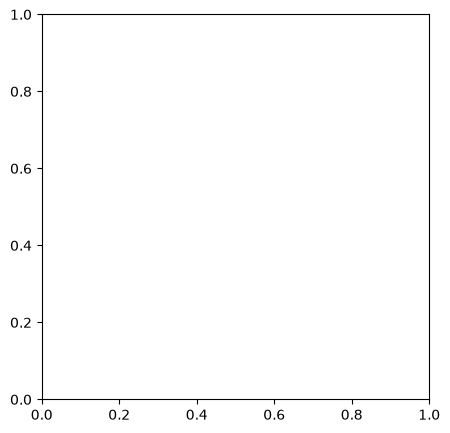

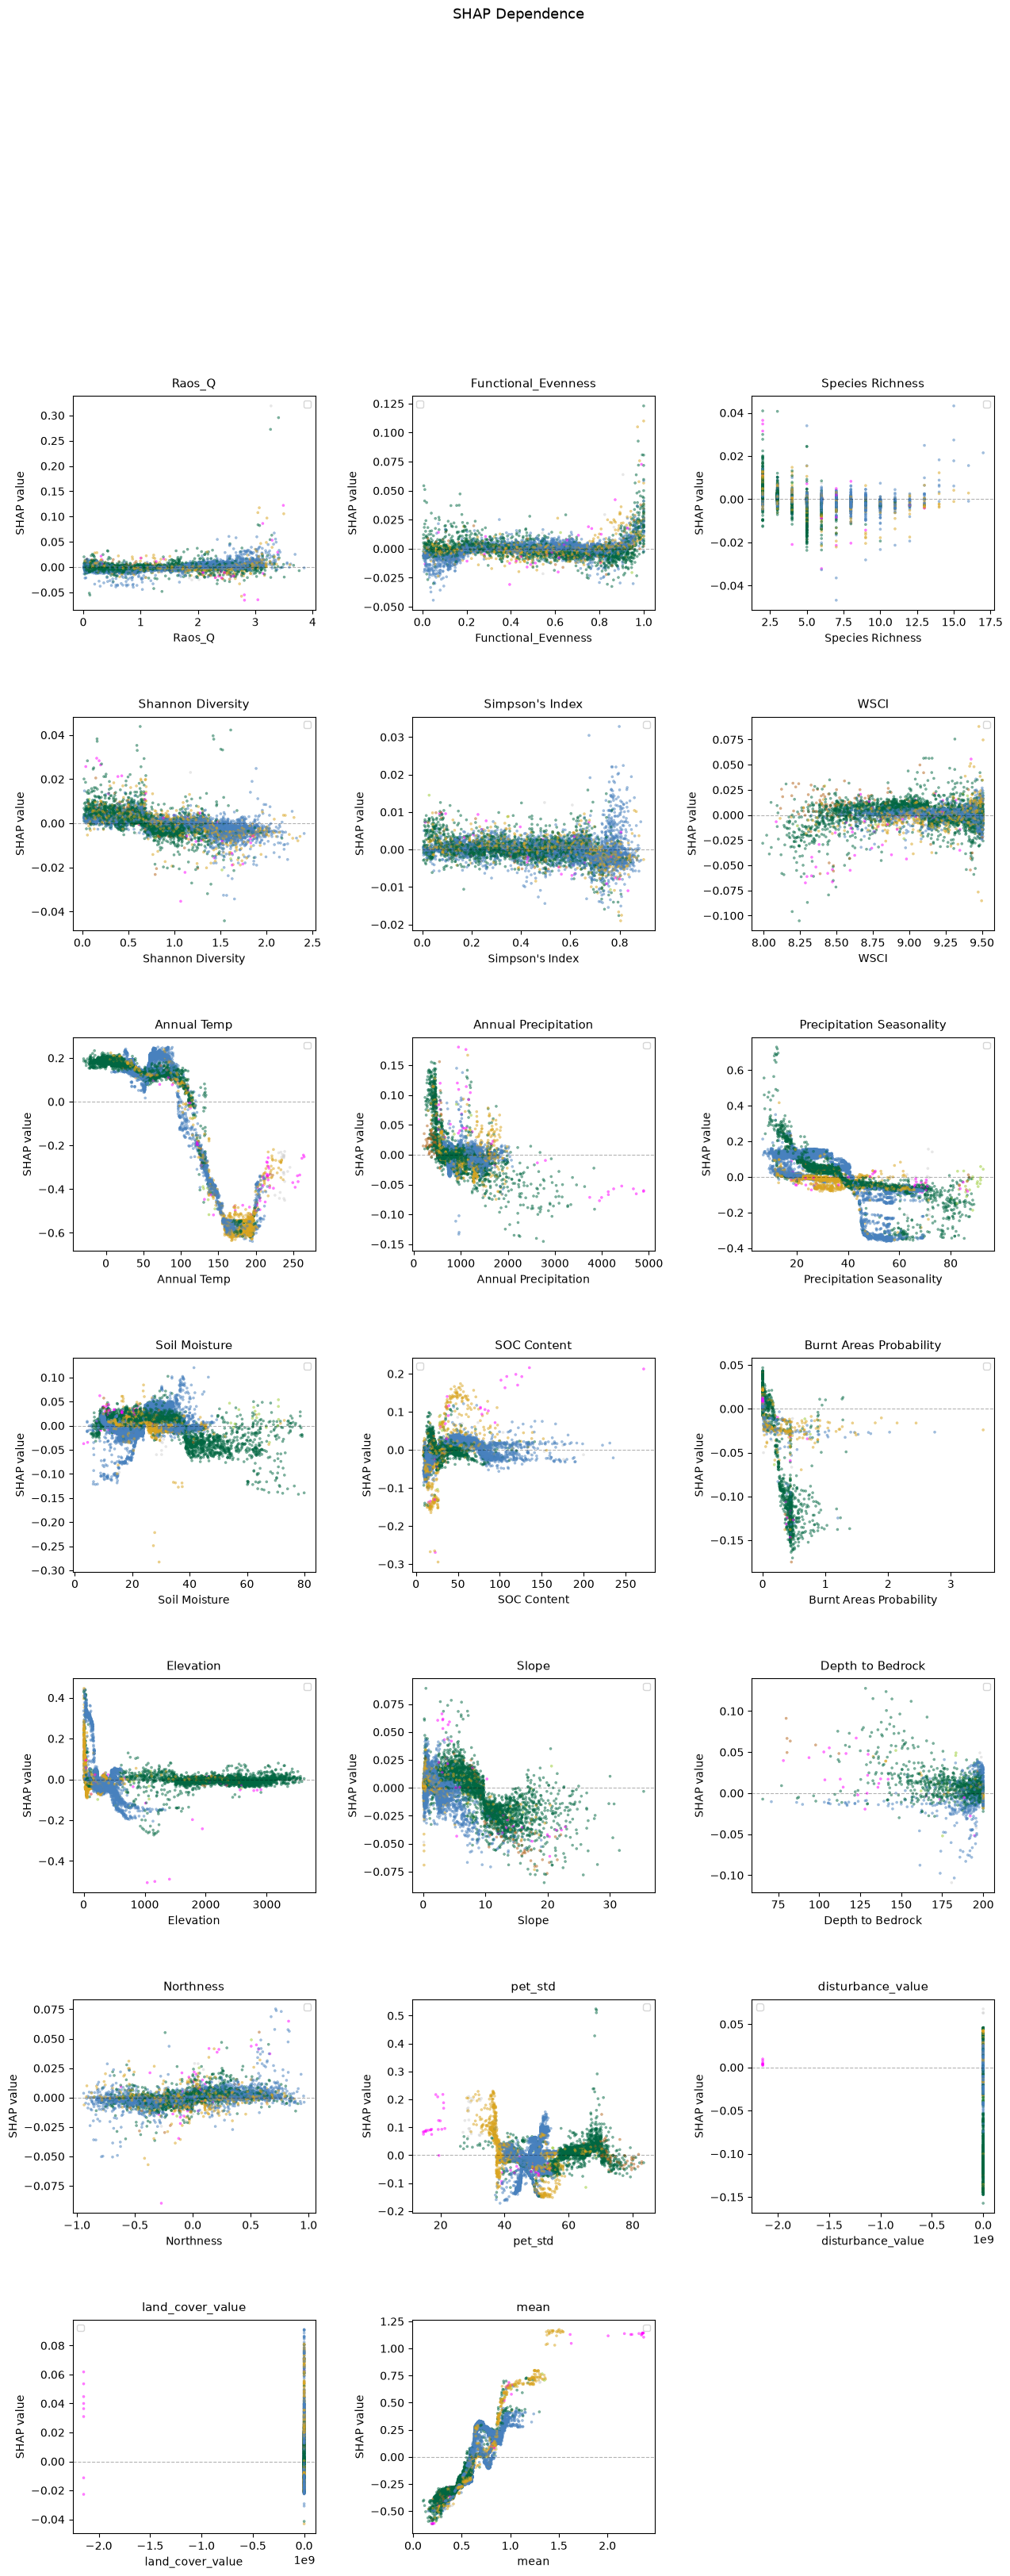

[np.float64(0.0026574340228455477), np.float64(0.006799553550455354), np.float64(-0.0010645288066271693), np.float64(-0.005467886145575402), np.float64(-0.0027852994807266492), np.float64(-0.015030112057565215), np.float64(-0.0028473678485623614), np.float64(-3.526550640872329e-05), np.float64(-0.006169513194311945), np.float64(0.00010966202375093412), np.float64(0.0008005342127118448), np.float64(-0.24356970386138285), np.float64(-7.725459253651575e-05), np.float64(-0.001955361865898073), np.float64(-0.00040999584131887093), np.float64(0.006812982778128441), np.float64(-0.0001383928447972766), np.float64(-0.013115145577309308), np.float64(-0.00027609771187674727), np.float64(1.2591351986927992)]


/tmp/ipykernel_3945124/2053393225.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


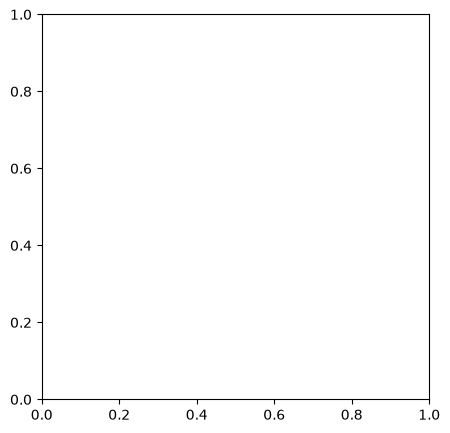

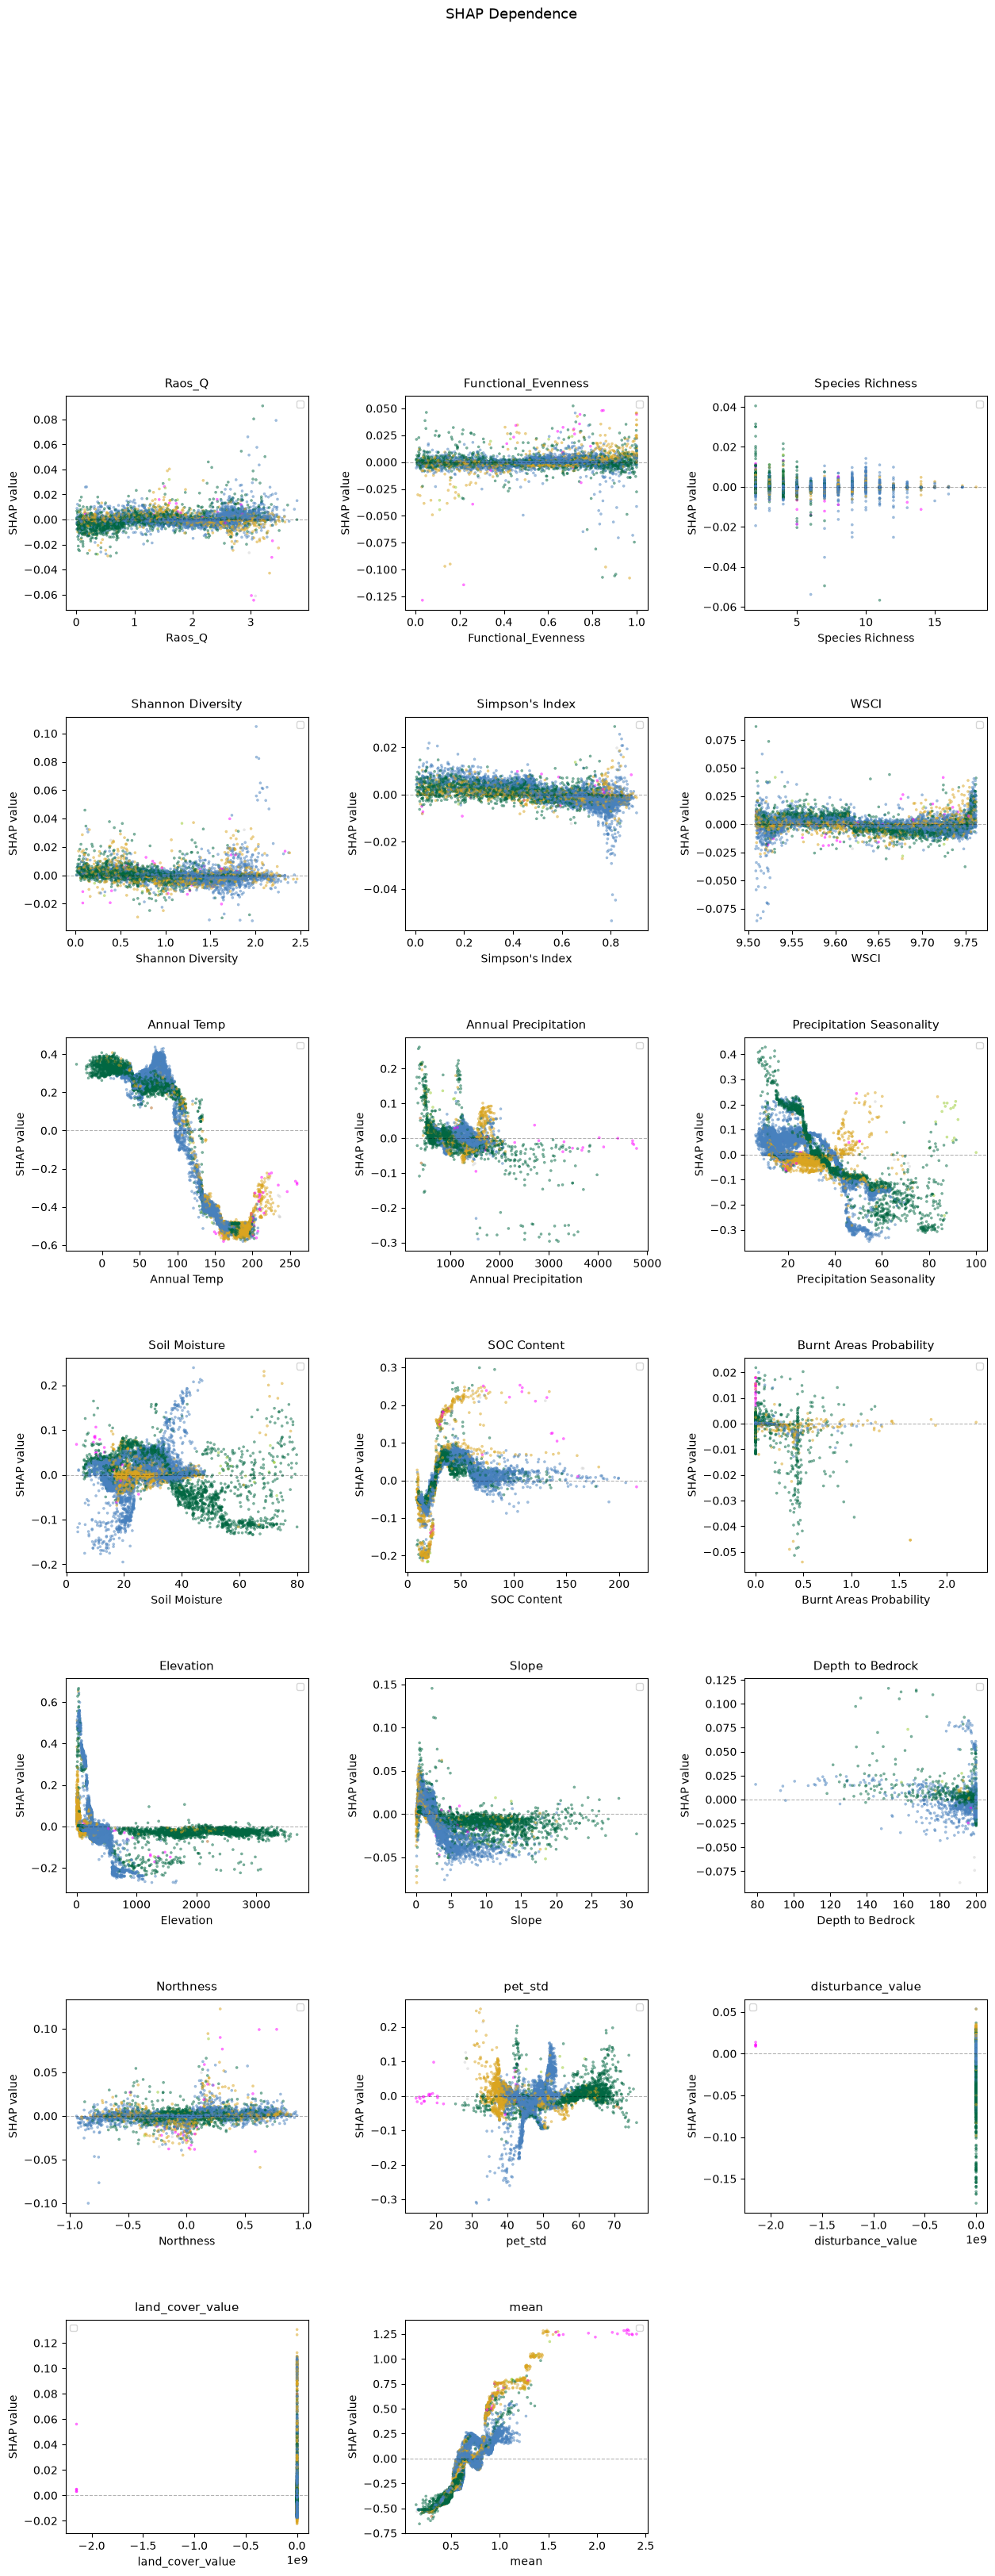

[np.float64(0.0012668026340755464), np.float64(0.003292712582154174), np.float64(-0.00015689457904705236), np.float64(-0.0014167295023331371), np.float64(-0.010979298979502724), np.float64(-0.005578947795779499), np.float64(-0.004803029438660256), np.float64(-3.176169685566052e-05), np.float64(-0.0044121873771308644), np.float64(-2.671512641947804e-05), np.float64(0.0028432017747202793), np.float64(-0.01855257487806946), np.float64(-0.0001683933159900845), np.float64(-0.005646637783050879), np.float64(-0.000311762088147074), np.float64(0.0032748024979451914), np.float64(0.0007173351714052146), np.float64(-0.005925023017959025), np.float64(-0.0006320784335249361), np.float64(1.299588971688301)]


/tmp/ipykernel_3945124/2053393225.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


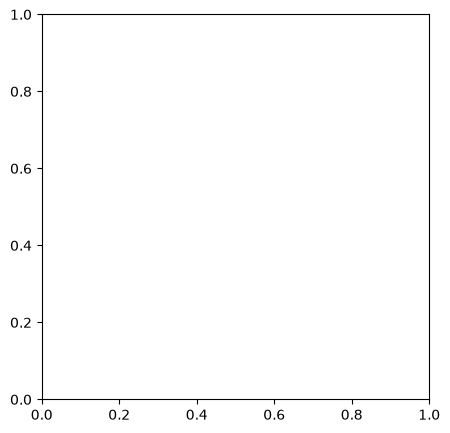

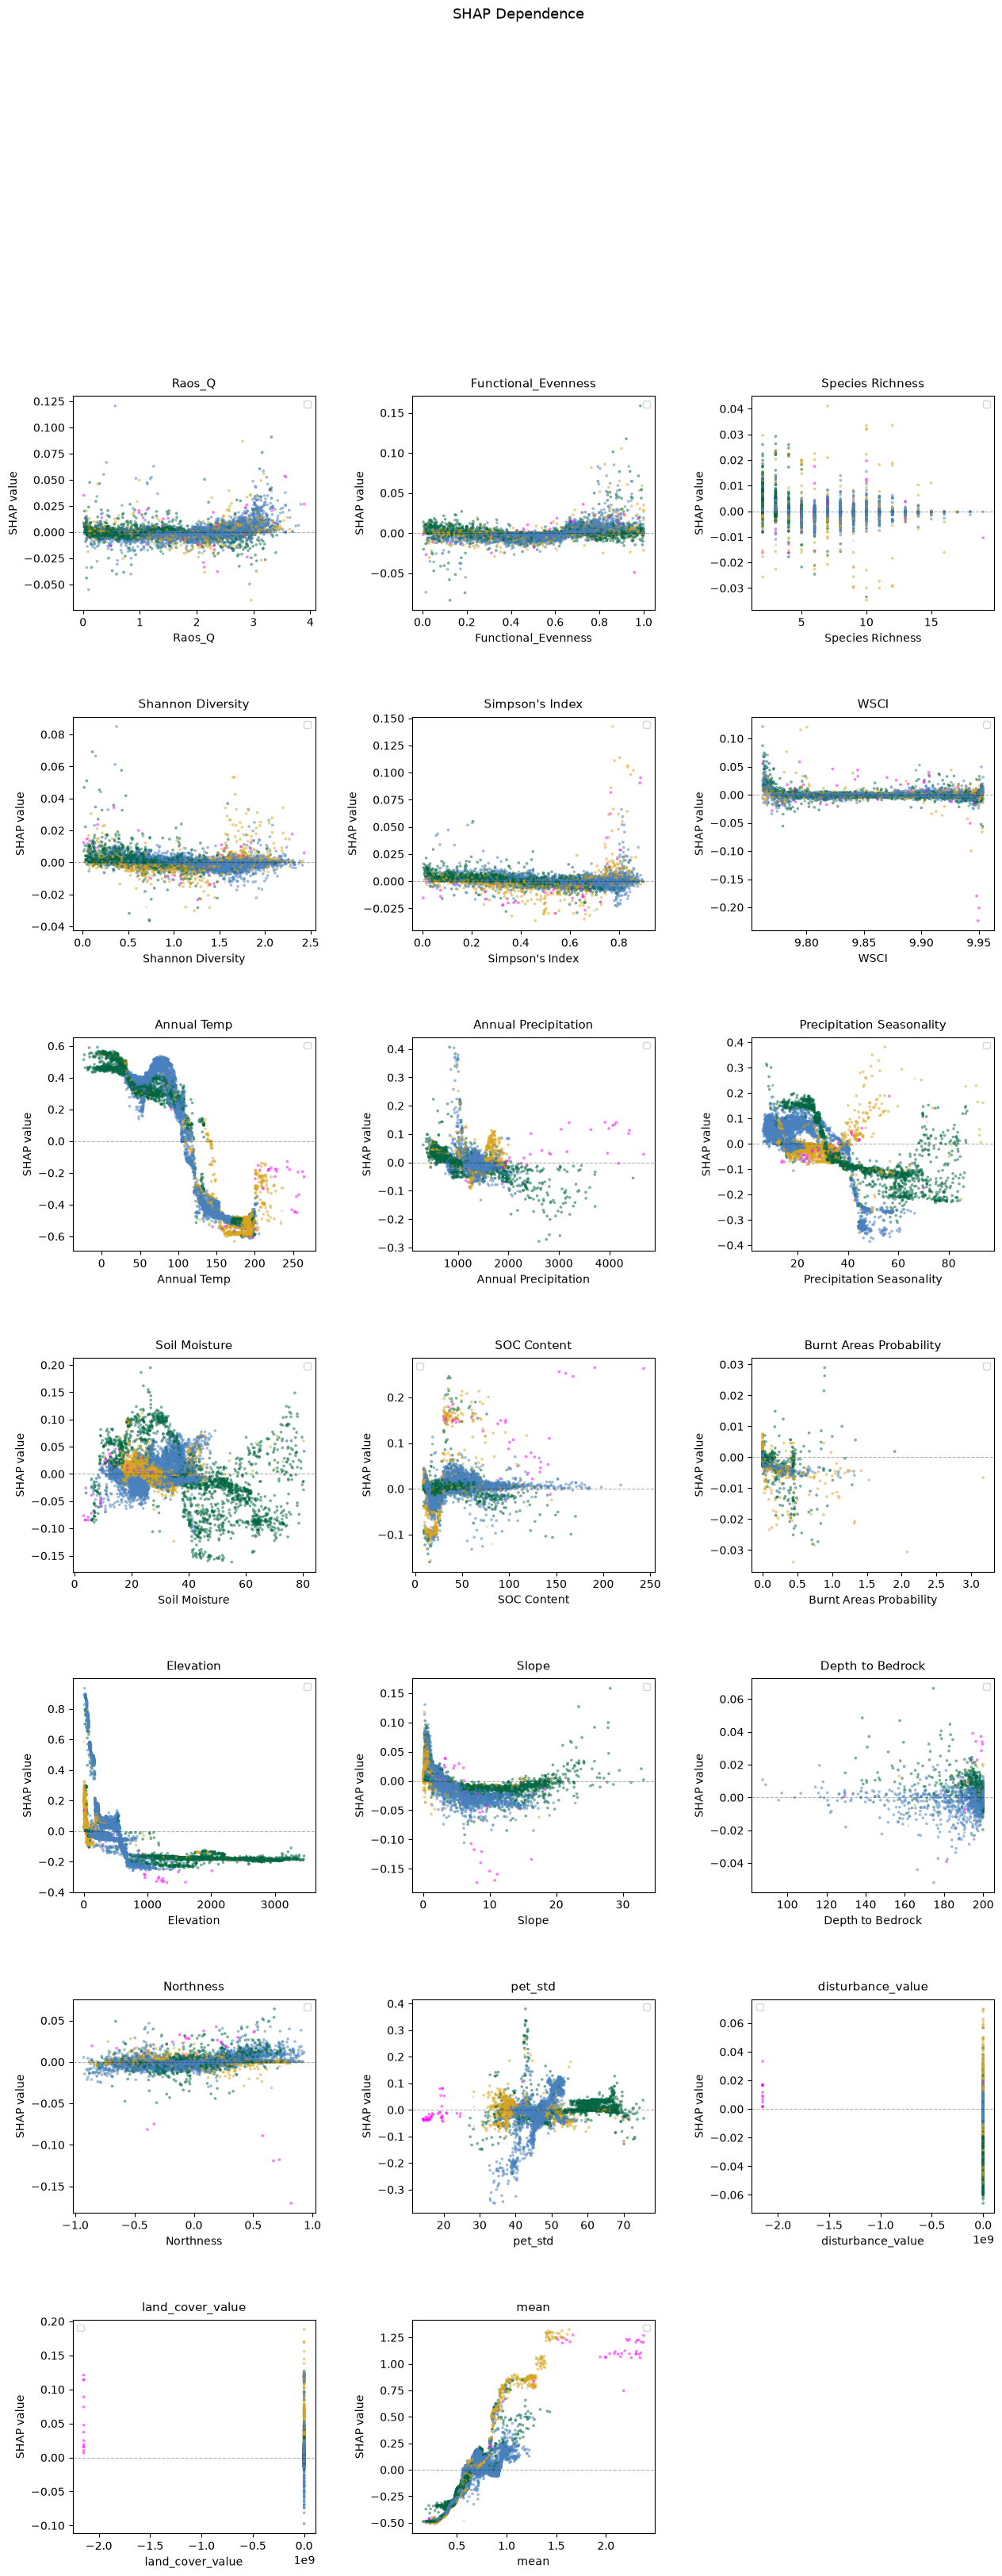

[np.float64(0.002990713307437002), np.float64(0.01819442063464586), np.float64(-0.000246239029199346), np.float64(-0.0011531213717429368), np.float64(0.006041359245493275), np.float64(-0.021822369341128578), np.float64(-0.006609047774794444), np.float64(-3.7387461121823444e-05), np.float64(-0.004590915390163833), np.float64(-0.0005566367580111647), np.float64(0.0006415380060608633), np.float64(-0.015259291518460234), np.float64(-0.00029115592991014745), np.float64(-0.006631460033535099), np.float64(-4.820822297394305e-05), np.float64(0.006168737143925599), np.float64(0.0012986107363483776), np.float64(-0.0030133142509828634), np.float64(-0.000566259924120157), np.float64(1.0662692959580857)]


/tmp/ipykernel_3945124/2053393225.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


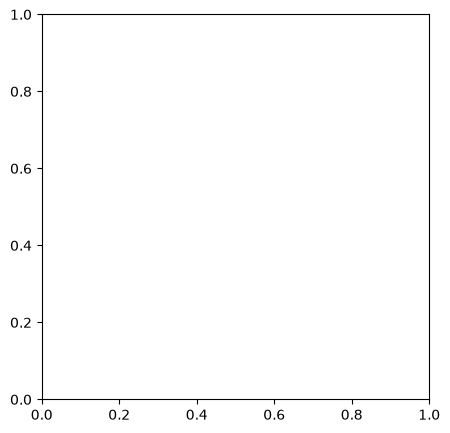

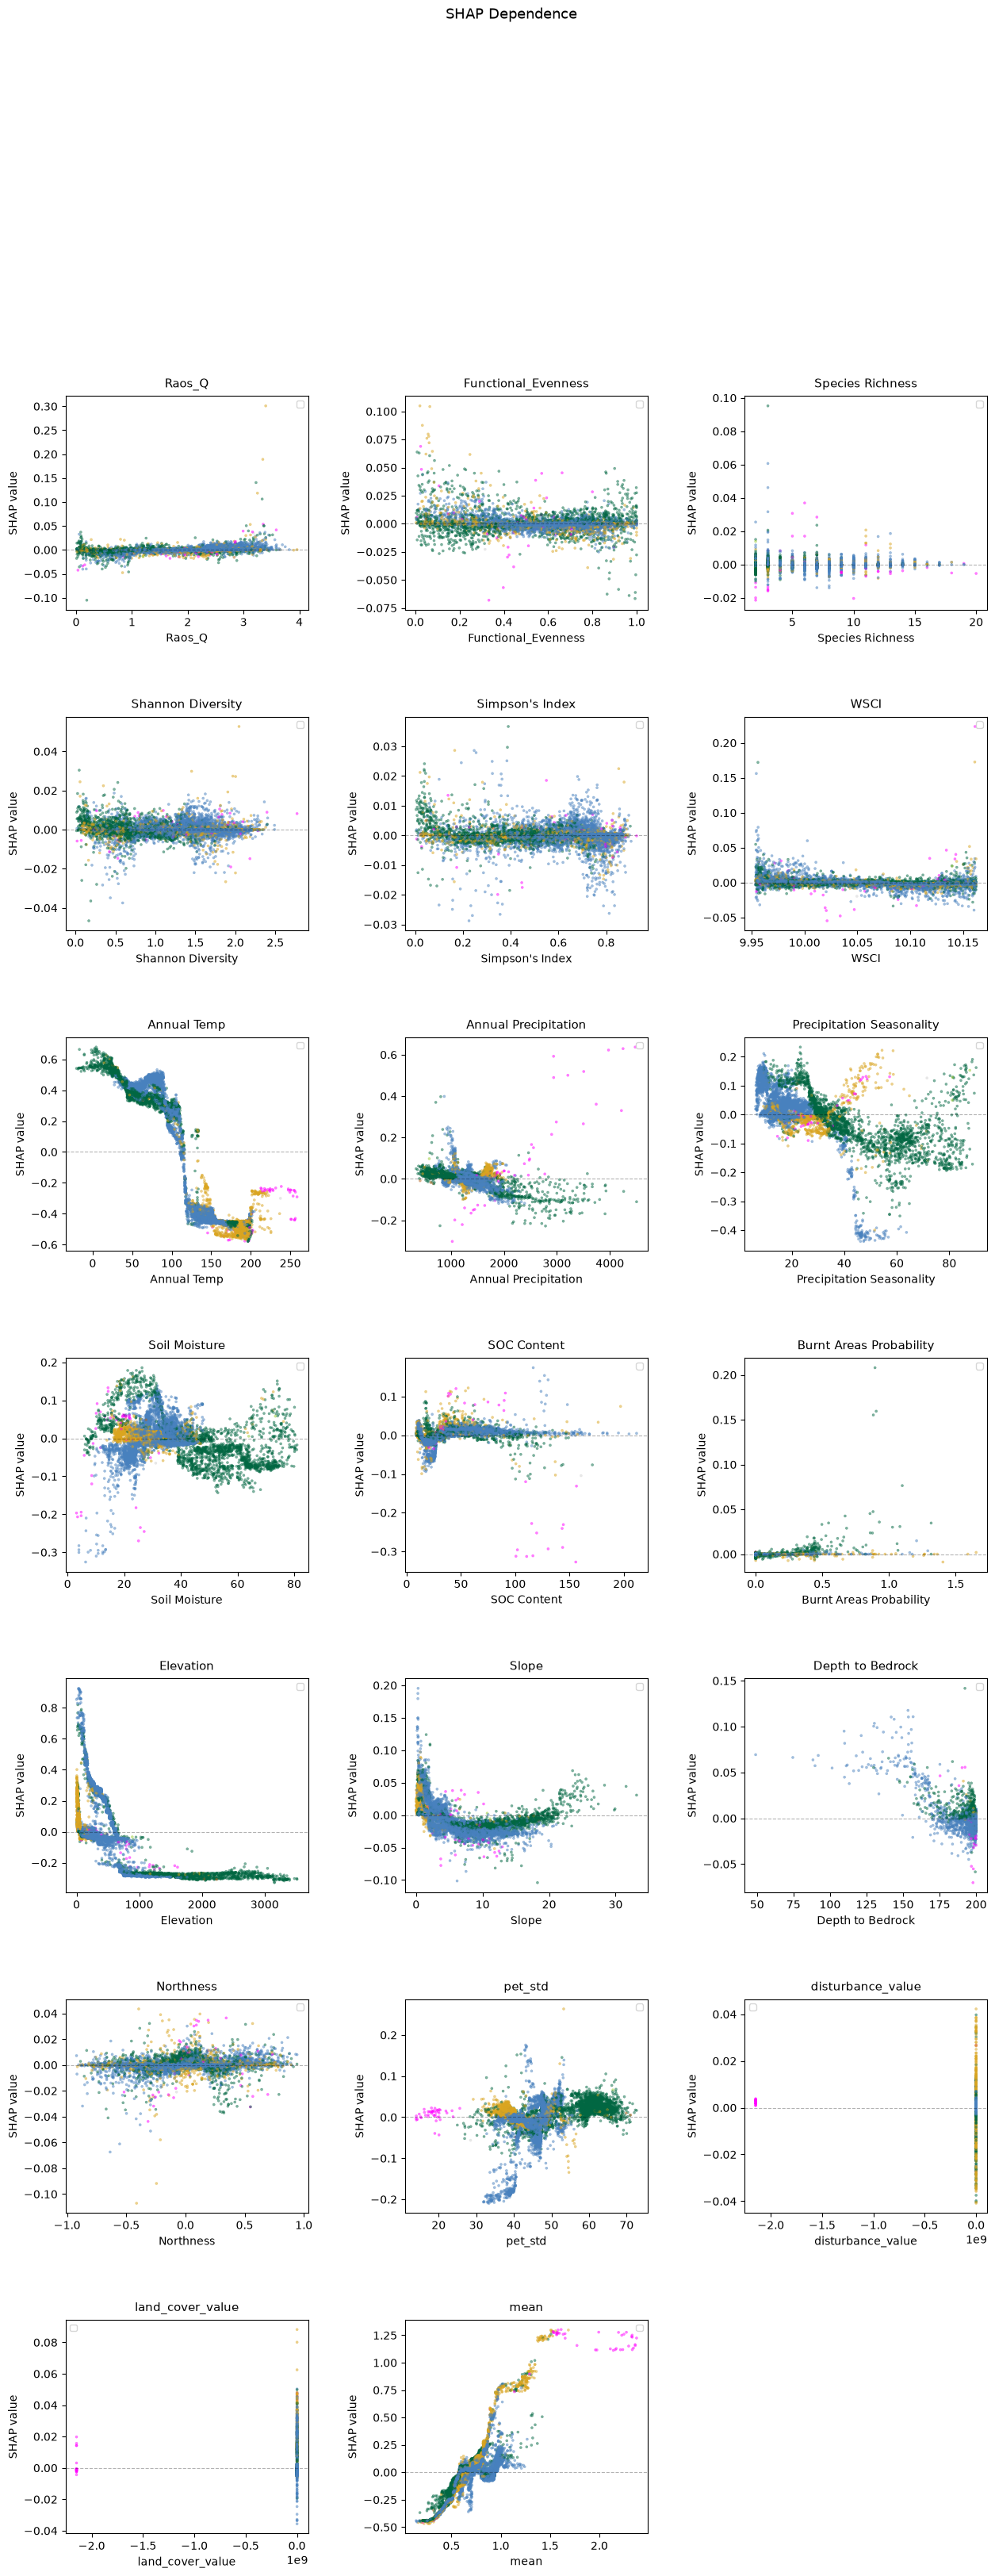

[np.float64(0.003201145939737914), np.float64(-0.0024577594273627462), np.float64(-8.718495633305203e-05), np.float64(0.0001384910191290496), np.float64(-0.000986355919009176), np.float64(-0.03707907719823389), np.float64(-0.007209051231386476), np.float64(-4.971931401509178e-05), np.float64(-0.004343918216055789), np.float64(-0.0003532005788936827), np.float64(0.00048217284658755126), np.float64(0.007610364829884109), np.float64(-0.00036384080116448907), np.float64(-0.006462415542663816), np.float64(-0.0006731498462435048), np.float64(0.002613647368931058), np.float64(0.0017262434059922029), np.float64(-0.0012678898668572877), np.float64(-0.00019175763286932224), np.float64(0.9202847758030871)]


/tmp/ipykernel_3945124/2053393225.py:307: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


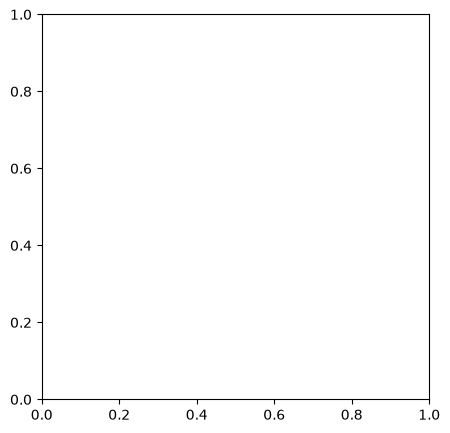

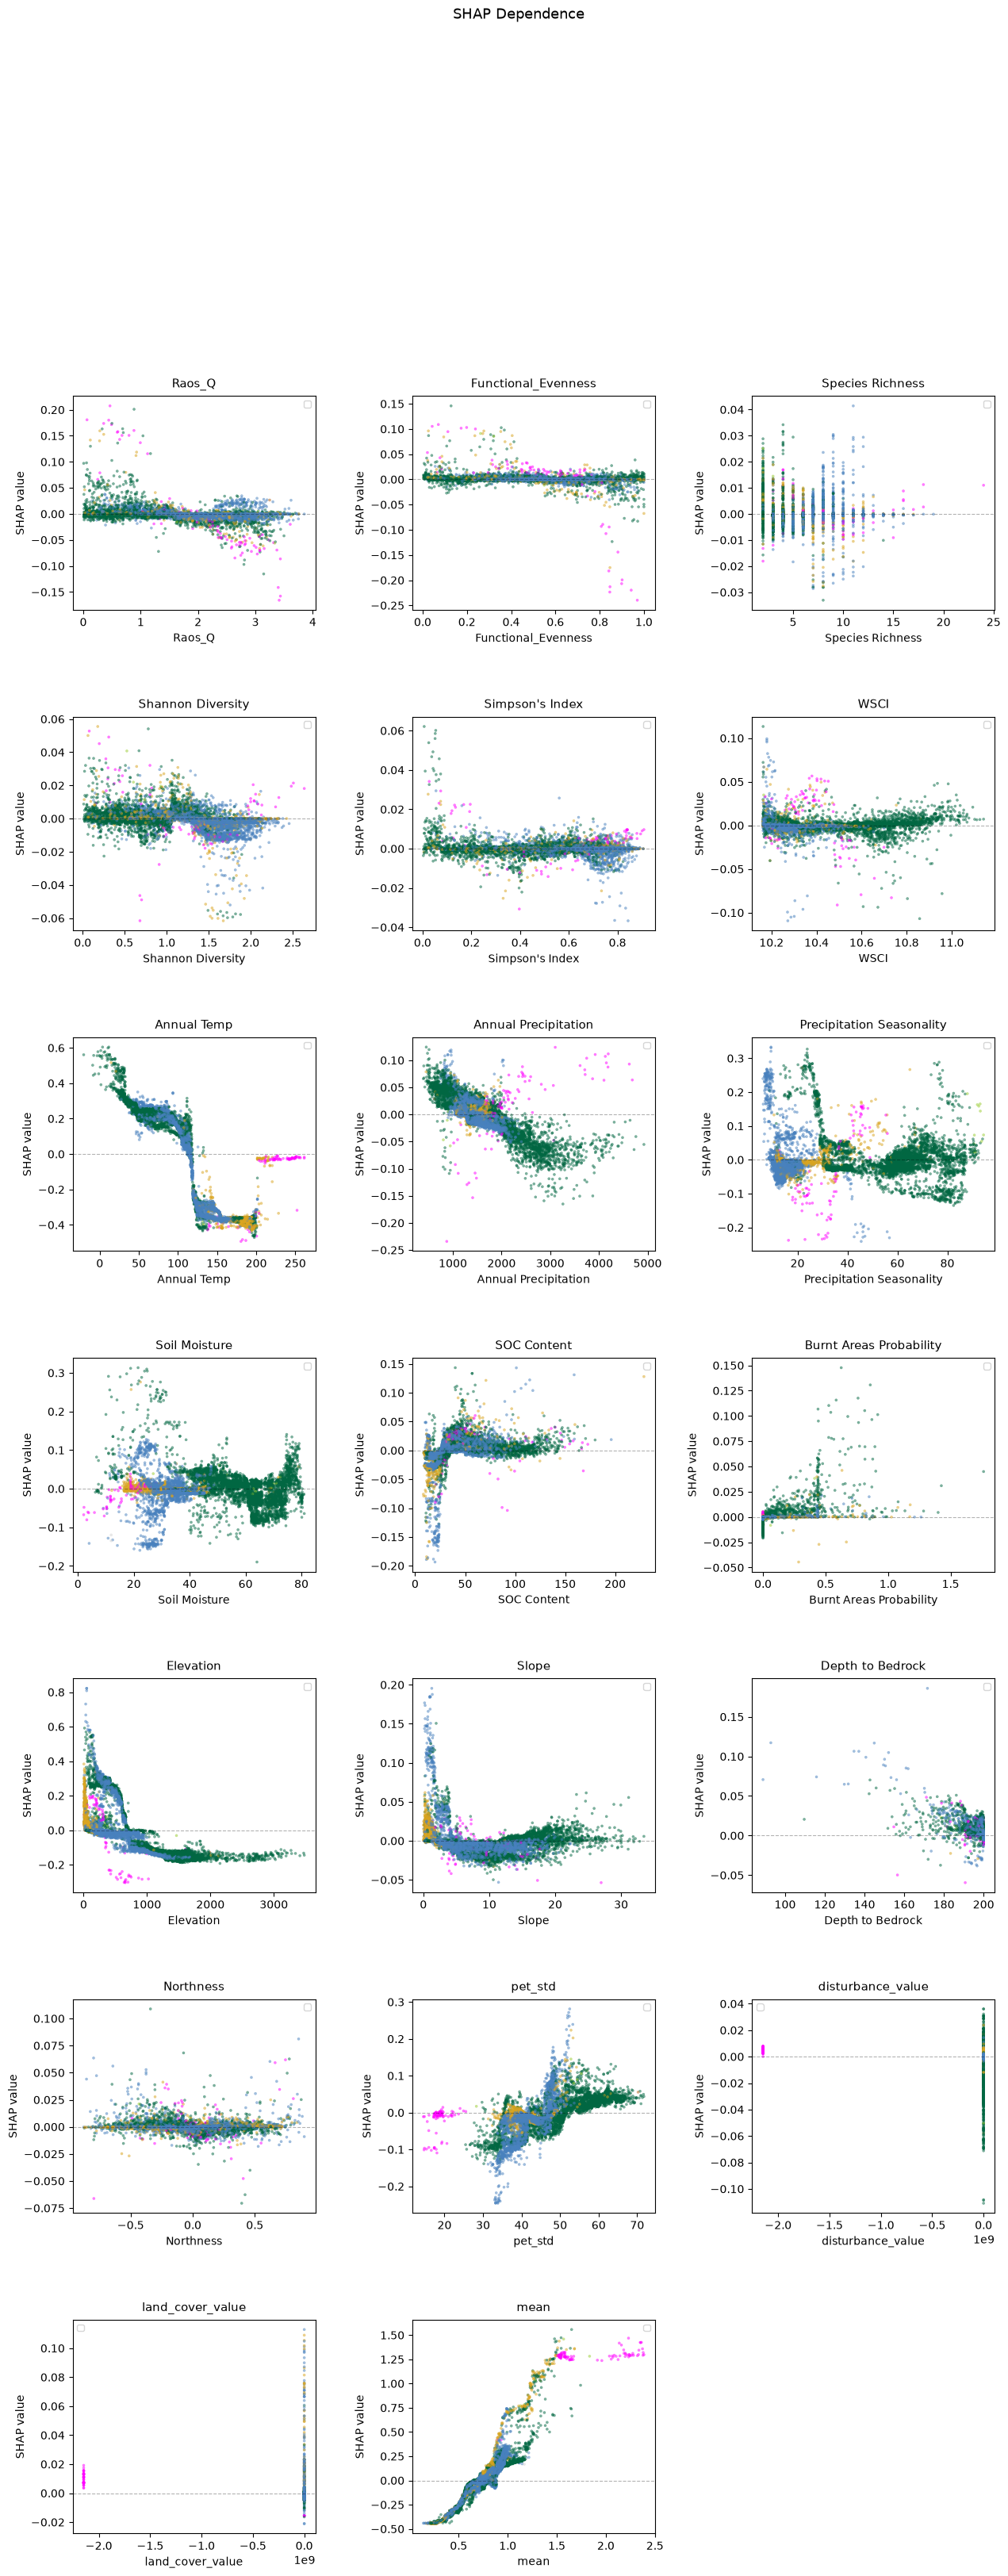

[np.float64(-0.004169306663320561), np.float64(-0.009711129762725937), np.float64(-0.00024097864761355055), np.float64(-0.0038731839140105345), np.float64(0.0005699194513510506), np.float64(-0.01919229069667505), np.float64(-0.00541904574716844), np.float64(-5.656599787655229e-05), np.float64(-0.000391461594186919), np.float64(-0.0003623216777363852), np.float64(0.0006205085625123972), np.float64(0.04564936099898199), np.float64(-0.00020419105446055097), np.float64(-0.0015229729428148176), np.float64(-0.0013067283639262304), np.float64(-0.001456462113281544), np.float64(0.00335018959724097), np.float64(-0.0013759811240231777), np.float64(-0.0003071389872562405), np.float64(1.0761827272113196)]


In [12]:
shap_df=pd.DataFrame(columns=['group', 'feature', 'mean_abs_shap'])
shap_df2=pd.DataFrame()
shap_df3=pd.DataFrame()
slopes_df=pd.DataFrame(columns=['group', 'feature', 'slope', 'zero_points'])
pdp_curves = {}  

for i, df in enumerate(dfs, start=1):
    X=df.drop(columns=[ 'transformed npp', 'PID', 'lat', 'lon', 'biome', 'treecover2000',  'WSCI_group'])
    y=df['transformed npp'].values
    scaler= StandardScaler()
    scaler.fit_transform(X)
    X = pd.DataFrame(
        X,
        columns=scaler.feature_names_in_
    )
    X1=df.drop(columns=['transformed npp', 'PID', 'lat', 'lon','treecover2000', 'WSCI_group'])


    model = xgb.XGBRegressor(**config["global"])
    model.fit(X, y )

    explainer = shap.Explainer(model, approximate=True)

    shap_vals = explainer.shap_values(X, approximate=True)
    mean_shap = shap_vals.mean(axis=0)
    model_features = getattr(model, "feature_names_in_", X.columns)
    shap_values = explainer(X, approximate=True )

    all_shap_df = pd.DataFrame(
        shap_vals,
        columns=[f'shap_{col}' for col in X.columns],
        index=X.index
    )
    all_shap_df = pd.concat(
        [
            df.loc[df.index, ["PID", "lat", "lon",  'WSCI_group']].reset_index(drop=True),
            all_shap_df.reset_index(drop=True)
        ],
        axis=1
    )
    shap_df3 = pd.concat([shap_df3, all_shap_df], ignore_index=False)

    shap_importance = pd.DataFrame({
    "group": f'WSCI Group {i}',
    "feature": model_features,
    "mean_abs_shap": np.abs(mean_shap)
    }).sort_values("mean_abs_shap", ascending=False)

    all_shap_df = pd.DataFrame(
        shap_vals,
        columns=[f'shap_{col}' for col in X.columns],
        index=X.index
    )
    results = pd.concat(
        [
            df.loc[df.index, ["PID", "lat", "lon"]].reset_index(drop=True),
            all_shap_df.reset_index(drop=True)
        ],
        axis=1
    )
    shap_df2 = pd.concat([shap_df2,results], ignore_index=False)


    diversity_vars = ['Raos_Q', 'Functional_Evenness', 'Species Richness']

    diversity_vars_f = ['Raos_Q', 'Functional_Evenness']
    diversity_vars_s = ["Simpson's Index", 'Shannon Diversity', 'Species Richness']

    # Sum SHAP importance within each group
    functional_sum =np.abs(shap_importance.loc[
        shap_importance['feature'].isin(diversity_vars_f), 'mean_abs_shap'
    ].sum())

    species_sum = np.abs(shap_importance.loc[
        shap_importance['feature'].isin(diversity_vars_s), 'mean_abs_shap'
    ].sum())

    # Remove all individual diversity variables (union of both lists) from the table
    all_diversity_vars = set(diversity_vars_f) | set(diversity_vars_s)
    shap_importance_combined = shap_importance[
        ~shap_importance['feature'].isin(all_diversity_vars)
    ].copy()

    # Add the two combined rows
    summary_rows = pd.DataFrame({
        'feature': ['Functional Diversity (combined)', 'Species Diversity (combined)'],
        'mean_abs_shap': [functional_sum, species_sum], 
        'group': [f'WSCI Group {i}', f'WSCI Group {i}']
    })

    shap_importance_combined = pd.concat(
        [shap_importance_combined, summary_rows], ignore_index=True
    ).sort_values('mean_abs_shap', ascending=False)

    shap_df = pd.concat([shap_df, shap_importance_combined], ignore_index=True)


    # Plot
    fig, ax = plt.subplots(figsize=(5,5))
    colors = ['#d62728' if f in summary_rows['feature'].values else '#1f77b4'
            for f in shap_importance_combined['feature']]

    # bars = ax.barh(
    #     shap_importance_combined['feature'],
    #     shap_importance_combined['mean_abs_shap'],
    #     color=colors
    # )
    # ax.invert_yaxis()
    # ax.set_xlabel('Mean |SHAP value|')
    # ax.set_title(f'Feature Importance Richness {i} (Diversity Metrics Combined)')

    # plt.tight_layout()
    # plt.show()

    

    slopes, zeros = plot_shap_with_polynomial_stats_v3(shap_vals, X1, model_features,
                                                    biome_colors, biome_col="biome", 
                                                    degree=2, name=None)

    # Splines to fit line or binning  
    print(slopes)
    slopes_df = pd.concat([slopes_df, pd.DataFrame({
        'group': i,
        'feature': model_features,
        'slope': slopes,
        'zero_points': zeros
    })], ignore_index=True)


In [ ]:
shap_df

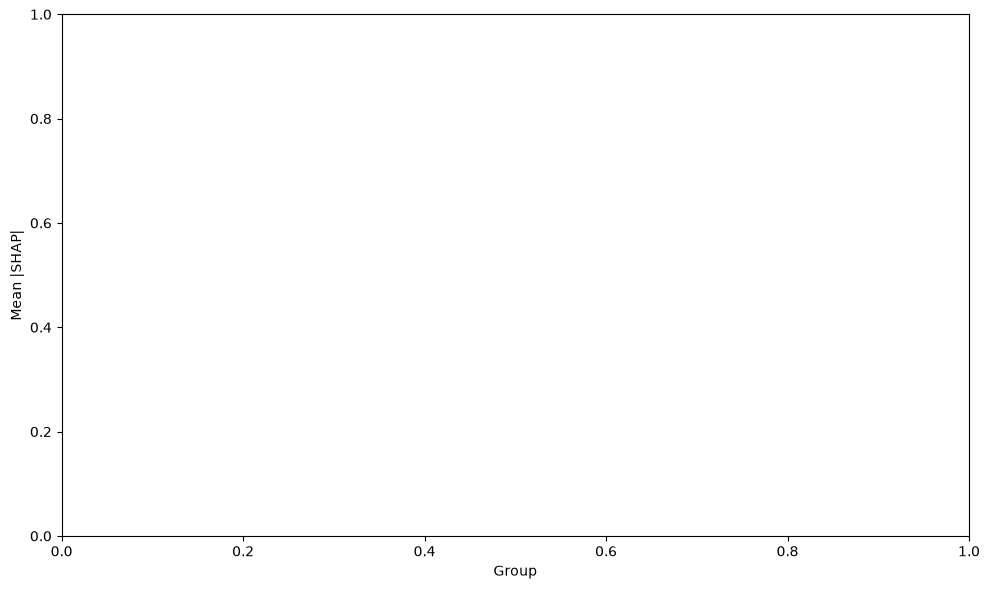

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = shap_df[
    shap_df["feature"].isin(["Functional Diversity (combined)", "Species Diversity (combined)"])
].copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_df,
    x="group",
    y="mean_abs_shap",
    hue="feature"
)

plt.xlabel("Group")
plt.ylabel("Mean |SHAP|")
plt.tight_layout()
plt.show()

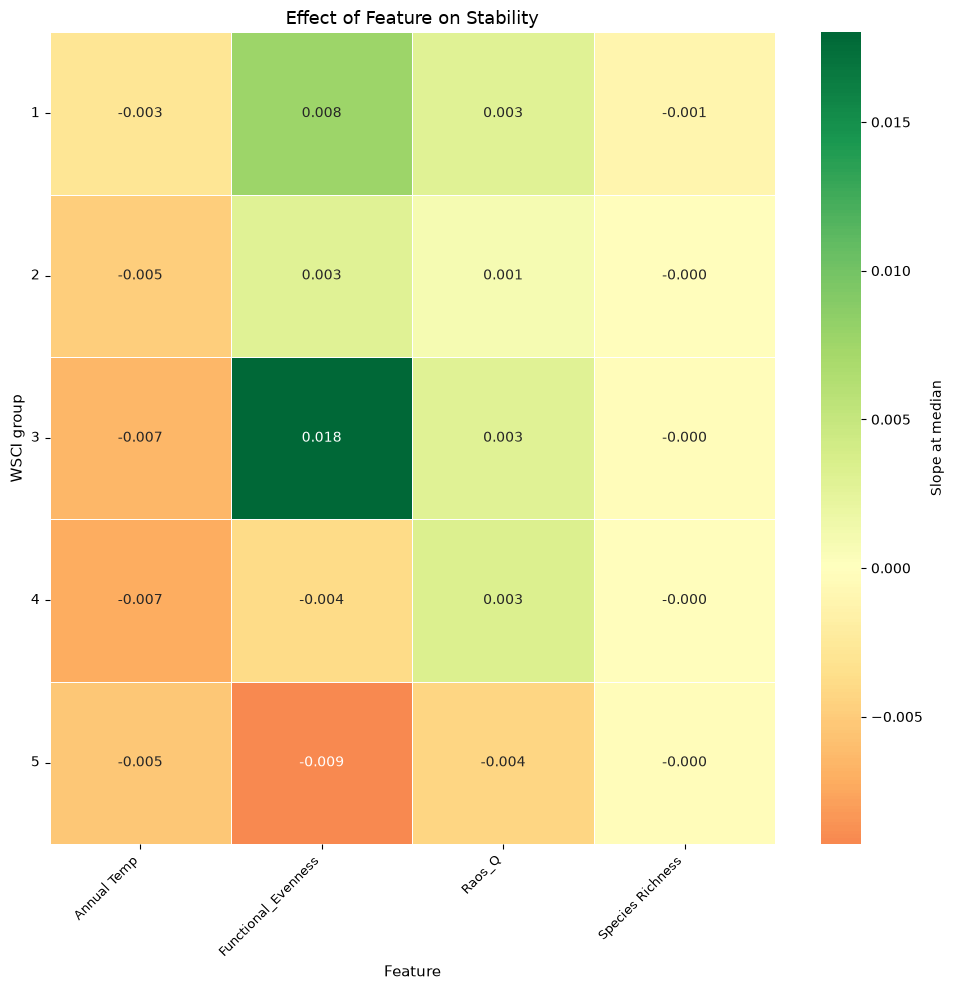

In [ ]:
slopes_df['slope'] = pd.to_numeric(slopes_df['slope'], errors='coerce')

slope_pivot = slopes_df.pivot(index='group', columns='feature', values='slope')

fig, ax = plt.subplots(figsize=(10,10))

sns.heatmap(
    slope_pivot,
    cmap='RdYlGn',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Slope at median\n'}
)

ax.set_title('Effect of Feature on Stability', fontsize=13)
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('WSCI group', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
shap_df3.to_csv('data/final/shap_values_all_wsci_stratisfy.csv', index=False)